<a href="https://colab.research.google.com/github/abhishek-ganjigatti/Leaf_image_detection/blob/master/plf_dl_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! gdown --id 13phPUUxz6Zy6HJqPOIZ00o4EFIGS479q

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13phPUUxz6Zy6HJqPOIZ00o4EFIGS479q
From (redirected): https://drive.google.com/uc?id=13phPUUxz6Zy6HJqPOIZ00o4EFIGS479q&confirm=t&uuid=dc9c911a-5ae5-4e59-898d-6a7d9839a61d
To: /content/leafsnap-dataset.zip
100% 244M/244M [00:03<00:00, 71.9MB/s]


In [ ]:
from zipfile import ZipFile # Import the ZipFile class

with ZipFile('leafsnap-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
pip install split-folders

In [ ]:
import random
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers
import splitfolders  # To install: pip install split-folders

# Set seeds for reproducibility
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

# Define the path to the original dataset
original_dataset_path = 'leafsnap-dataset/'

# Define the path to the new dataset
new_dataset_path = 'leafsnap-dataset2/'

# Create the new dataset directory if it doesn't exist
os.makedirs(new_dataset_path, exist_ok=True)

# Function to resize image
def resize_image(img, target_size):
    img_pil = Image.fromarray((img * 255).astype(np.uint8))  # Convert to PIL image
    img_resized = img_pil.resize(target_size)
    return np.array(img_resized) / 255.0  # Convert back to numpy array

# Resize target dimensions
resize_target = (128, 128)

# Iterate through each folder and each image
for folder in os.listdir(original_dataset_path):
    folder_path = os.path.join(original_dataset_path, folder)
    new_folder_path = os.path.join(new_dataset_path, folder)
    os.makedirs(new_folder_path, exist_ok=True)
    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            new_image_path = os.path.join(new_folder_path, image_name)
            if os.path.isfile(image_path):
                # Read the image
                img = mpimg.imread(image_path)
                # Resize image
                img = resize_image(img, resize_target)
                # Save the transformed image to the new dataset path
                mpimg.imsave(new_image_path, img)

print("Image transformation and copying completed.")

# Split the dataset into train and validation sets
dataset_path = 'leafsnap-dataset2/'
output_dir = 'leafsnap-dataset-split/'

splitfolders.ratio(dataset_path, output=output_dir, seed=42, ratio=(.8, .2), group_prefix=None)

# Define paths for train and validation directories
train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'val')

# Create ImageDataGenerators for train and validation
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
validation_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=resize_target,
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=resize_target,
    batch_size=32,
    class_mode='categorical'
)

print("Train and Validation Generators created.")

# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10  # You can increase this for better results
)

# Evaluate the model
val_loss, val_acc = model.evaluate(validation_generator, steps=validation_generator.samples // validation_generator.batch_size)
print(f'Validation accuracy: {val_acc}, Validation loss: {val_loss}')

Image transformation and copying completed.


Copying files: 7719 files [00:01, 6517.92 files/s]


Found 6109 images belonging to 184 classes.
Found 1610 images belonging to 184 classes.
Train and Validation Generators created.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0   

In [ ]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...


NameError: name 'batch_size' is not defined

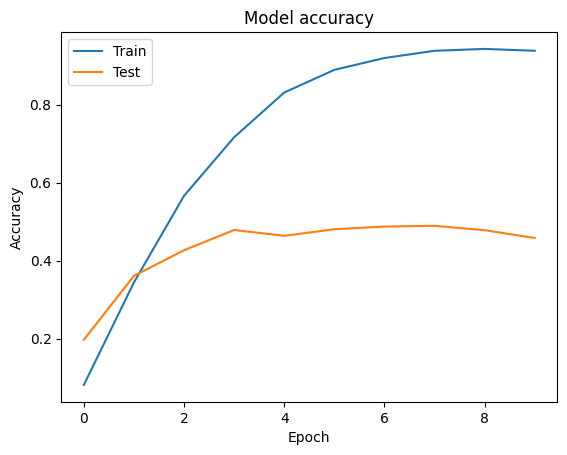

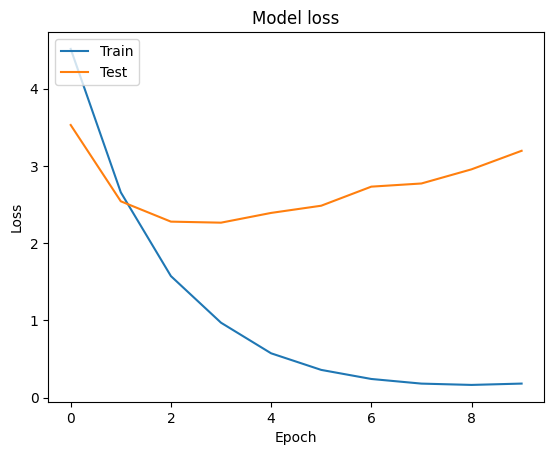

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(128, 128)): # Change target size to (128,128)
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

NameError: name 'train_generator' is not defined

In [ ]:
class_indices

{0: 'abies_concolor',
 1: 'abies_nordmanniana',
 2: 'acer_campestre',
 3: 'acer_ginnala',
 4: 'acer_griseum',
 5: 'acer_negundo',
 6: 'acer_palmatum',
 7: 'acer_pensylvanicum',
 8: 'acer_platanoides',
 9: 'acer_pseudoplatanus',
 10: 'acer_rubrum',
 11: 'acer_saccharinum',
 12: 'acer_saccharum',
 13: 'aesculus_flava',
 14: 'aesculus_glabra',
 15: 'aesculus_hippocastamon',
 16: 'aesculus_pavi',
 17: 'ailanthus_altissima',
 18: 'albizia_julibrissin',
 19: 'amelanchier_arborea',
 20: 'amelanchier_canadensis',
 21: 'amelanchier_laevis',
 22: 'asimina_triloba',
 23: 'betula_alleghaniensis',
 24: 'betula_jacqemontii',
 25: 'betula_lenta',
 26: 'betula_nigra',
 27: 'betula_populifolia',
 28: 'broussonettia_papyrifera',
 29: 'carpinus_betulus',
 30: 'carpinus_caroliniana',
 31: 'carya_cordiformis',
 32: 'carya_glabra',
 33: 'carya_ovata',
 34: 'carya_tomentosa',
 35: 'castanea_dentata',
 36: 'catalpa_bignonioides',
 37: 'catalpa_speciosa',
 38: 'cedrus_atlantica',
 39: 'cedrus_deodara',
 40: 'c

In [ ]:
import json

# Assuming `class_indices` is your dictionary or data structure containing class names
json.dump(class_indices, open('class_indices.json', 'w'))


In [ ]:
# Example Usage
image_path = '/content/leafsnap-dataset-split/val/acer_campestre/13291732974447.jpg'
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 [==============================] - 0s 55ms/step
Predicted Class Name: acer_campestre


In [ ]:
model.save('drive/MyDrive/ksam/plant_disease_prediction_model.h5')

In [ ]:
model.save('plant_disease_prediction_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
pip install split-folders

In [ ]:
import random
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers, callbacks
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import splitfolders  # To install: pip install split-folders

# Set seeds for reproducibility
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)


In [ ]:
# Define the path to the original dataset
original_dataset_path = 'leafsnap-dataset/'

# Define the path to the new dataset
new_dataset_path = 'leafsnap-dataset2/'

# Create the new dataset directory if it doesn't exist
os.makedirs(new_dataset_path, exist_ok=True)


In [ ]:
# Function to resize image
def resize_image(img, target_size):
    img_pil = Image.fromarray((img * 255).astype(np.uint8))  # Convert to PIL image
    img_resized = img_pil.resize(target_size)
    return np.array(img_resized) / 255.0  # Convert back to numpy array

# Resize target dimensions
resize_target = (128, 128)

# Iterate through each folder and each image
for folder in os.listdir(original_dataset_path):
    folder_path = os.path.join(original_dataset_path, folder)
    new_folder_path = os.path.join(new_dataset_path, folder)
    os.makedirs(new_folder_path, exist_ok=True)
    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            new_image_path = os.path.join(new_folder_path, image_name)
            if os.path.isfile(image_path):
                # Read the image
                img = mpimg.imread(image_path)
                # Resize image
                img = resize_image(img, resize_target)
                # Save the transformed image to the new dataset path
                mpimg.imsave(new_image_path, img)

print("Image transformation and copying completed.")


Image transformation and copying completed.


In [ ]:
# Function to resize image
def resize_image(img, target_size):
    img_pil = Image.fromarray((img * 255).astype(np.uint8))  # Convert to PIL image
    img_resized = img_pil.resize(target_size)
    return np.array(img_resized) / 255.0  # Convert back to numpy array

# Resize target dimensions
resize_target = (128, 128)

# Iterate through each folder and each image
for folder in os.listdir(original_dataset_path):
    folder_path = os.path.join(original_dataset_path, folder)
    new_folder_path = os.path.join(new_dataset_path, folder)
    os.makedirs(new_folder_path, exist_ok=True)
    if os.path.isdir(folder_path):
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            new_image_path = os.path.join(new_folder_path, image_name)
            if os.path.isfile(image_path):
                # Read the image
                img = mpimg.imread(image_path)
                # Resize image
                img = resize_image(img, resize_target)
                # Save the transformed image to the new dataset path
                mpimg.imsave(new_image_path, img)

print("Image transformation and copying completed.")


Image transformation and copying completed.


In [ ]:
# Split the dataset into train and validation sets
dataset_path = 'leafsnap-dataset2/'
output_dir = 'leafsnap-dataset-split/'

splitfolders.ratio(dataset_path, output=output_dir, seed=42, ratio=(.8, .2), group_prefix=None)


Copying files: 7719 files [00:01, 7567.44 files/s]


In [ ]:
# Define paths for train and validation directories
train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'val')


In [ ]:
# Create ImageDataGenerators for train and validation with data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=resize_target,
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=resize_target,
    batch_size=32,
    class_mode='categorical'
)

print("Train and Validation Generators created.")


Found 6109 images belonging to 184 classes.
Found 1610 images belonging to 184 classes.
Train and Validation Generators created.


In [ ]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.BatchNormalization())

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

# Compile the model with learning rate scheduling
optimizer = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 63, 63, 32)        0         
 g2D)                                                            
                                                                 
 batch_normalization_8 (Bat  (None, 63, 63, 32)        128       
 chNormalization)                                                
                                                                 
 conv2d_7 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                      

In [ ]:
# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=50,  # Increase epochs for better results
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)


Epoch 1/50
190/190 [==============================] - 32s 153ms/step - loss: 4.5952 - accuracy: 0.0729 - val_loss: 6.2333 - val_accuracy: 0.0100 - lr: 0.0010
Epoch 2/50
190/190 [==============================] - 30s 158ms/step - loss: 3.8455 - accuracy: 0.1223 - val_loss: 4.5606 - val_accuracy: 0.0619 - lr: 0.0010
Epoch 3/50
190/190 [==============================] - 30s 157ms/step - loss: 3.3681 - accuracy: 0.1762 - val_loss: 3.6320 - val_accuracy: 0.1544 - lr: 0.0010
Epoch 4/50
190/190 [==============================] - 29s 151ms/step - loss: 3.1296 - accuracy: 0.2072 - val_loss: 5.2124 - val_accuracy: 0.0887 - lr: 0.0010
Epoch 5/50
190/190 [==============================] - 30s 158ms/step - loss: 2.8339 - accuracy: 0.2506 - val_loss: 5.9006 - val_accuracy: 0.0950 - lr: 0.0010
Epoch 6/50
190/190 [==============================] - 30s 155ms/step - loss: 2.6801 - accuracy: 0.2753 - val_loss: 2.3333 - val_accuracy: 0.3425 - lr: 0.0010
Epoch 7/50
190/190 [==============================] 

In [ ]:
# Evaluate the model
val_loss, val_acc = model.evaluate(validation_generator, steps=validation_generator.samples // validation_generator.batch_size)
print(f'Validation accuracy: {val_acc}, Validation loss: {val_loss}')


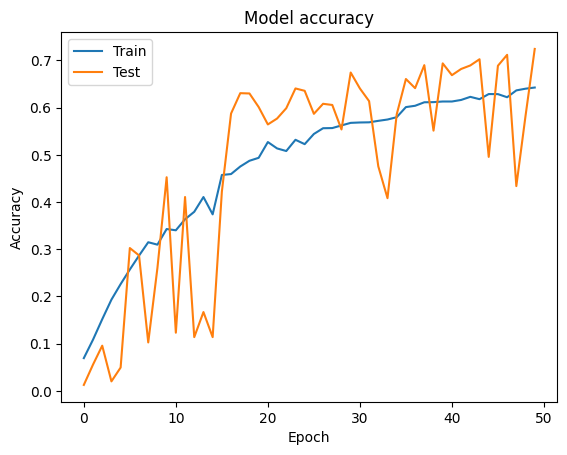

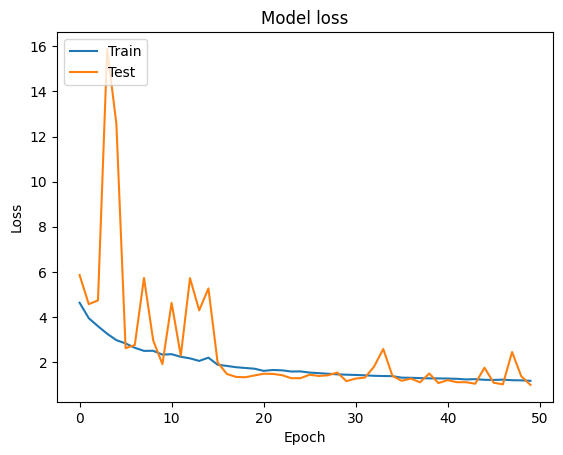

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
import shutil

In [ ]:
shutil.rmtree('leafsnap-dataset2')

NotADirectoryError: [Errno 20] Not a directory: 'best_model.h5'